In [1]:
import os
import sys
import numpy as np
import torch
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

from models.bottleneck import Bottleneck

from nnfabrik.builder import get_data, get_trainer
from modified_neuralpredictors.create_model import stacked_core_full_gauss_readout
from models.bottleneck import Bottleneck
from sensorium.utility.scores import get_correlations

In [2]:
random_seed = 42
torch.manual_seed(random_seed)
np.random.seed(random_seed)

device = 'cuda:7'
torch.cuda.set_device(device)

basepath = "/srv/user/polina/sensorium/sensorium/notebooks/data/"

# as filenames, we'll select all 7 datasets
filenames = [
    os.path.join(basepath, file) for file in os.listdir(basepath) if ".zip" in file
]

dataset_fn = "sensorium.datasets.static_loaders"
dataset_config = {
    "paths": filenames,
    "normalize": True,
    "include_behavior": True,
    "include_eye_position": True,
    "batch_size": 128,
    "scale": 0.25,
}

dataloaders = get_data(dataset_fn, dataset_config)

model_config = {
    'hidden_channels': 64, # original sensorium was 64ch
    'depth_separable': False,
    'use_avg_reg': False,
    'laplace_padding': None,
    'momentum': 0.75,
    'final_nonlinearity': True,
    'nonlinearity_type': 'AdaptiveELU',
    'pad_input': False,
    'hidden_padding': None, 
    'stack': -1,
    'layers': 4,
    'input_kern': 11, #  original sensorium was 'input_kern': 9,
    'gamma_input': 6.3831, # this should not influence the performance based on previous experience
    
    'feature_reg_weight': 3.0, # this is the one I actually would like to tune!
    
    'hidden_kern': 7,
    'grid_mean_predictor': {
        'type': 'cortex',
        'input_dimensions': 2,
        'hidden_layers': 1,
        'hidden_features': 30,
        'final_tanh': True
    },
    
    'init_sigma': 0.1,
    'init_mu_range': 0.3,
    'gauss_type': 'full',
    'shifter': True,
    'batch_norm_scale': [True, True, True, False],
    'core_bias': [True, True, True, False],
    'regularizer_type': "adaptive_log_norm",
    'gamma_sigma': 0.25,
}

data_keys = list(dataloaders['train'].keys())

model = stacked_core_full_gauss_readout(dataloaders, random_seed, **model_config)
model.to(device);
model.eval();

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
/srv/user/nathanpaul.soeding/neuralpredictors/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")


In [ ]:
base_paths = [
    # 'runs/newbase/nobehav64_seed0/model_weights.pth',
    # 'runs/newbase/nobehav64_seed42/model_weights.pth',
    # 'runs/newbase/nobehav64_seed123/model_weights.pth',
    'runs/newbase/dim64_seed0/model_weights.pth',
    'runs/newbase/dim64_seed42/model_weights.pth',
    'runs/newbase/dim64_seed123/model_weights.pth',
]

base_scores = []
base_maps = []

for base_path in base_paths:
    model = stacked_core_full_gauss_readout(dataloaders, random_seed, **model_config)
    model.to(device)
    model.load_state_dict(torch.load(base_path, map_location=device))
    
    for m in model.modules():
        if isinstance(m, torch.nn.BatchNorm2d) or isinstance(m, torch.nn.BatchNorm1d):
            m.running_mean = None
            m.running_var = None
    
    model.eval();
    
    score = get_correlations(
        model, dataloaders["validation"], device=device, as_dict=False, per_neuron=False 
    )
    base_scores.append(score)

    feature_maps = []
    for key in data_keys:
        for batch in dataloaders['validation'][key]:
            img, _, _, pupil = batch
            feature_map = model.core(img).detach().cpu()
            feature_maps.append(feature_map)
    base_maps.append(torch.cat(feature_maps))

base_scores = torch.tensor(base_scores)
base_mean = torch.mean(base_scores)
base_std = torch.std(base_scores)

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


BatchNorm2d(64, eps=1e-05, momentum=0.75, affine=True, track_running_stats=True)
BatchNorm2d(64, eps=1e-05, momentum=0.75, affine=True, track_running_stats=True)
BatchNorm2d(64, eps=1e-05, momentum=0.75, affine=True, track_running_stats=True)
BatchNorm2d(64, eps=1e-05, momentum=0.75, affine=False, track_running_stats=True)


Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


BatchNorm2d(64, eps=1e-05, momentum=0.75, affine=True, track_running_stats=True)
BatchNorm2d(64, eps=1e-05, momentum=0.75, affine=True, track_running_stats=True)
BatchNorm2d(64, eps=1e-05, momentum=0.75, affine=True, track_running_stats=True)
BatchNorm2d(64, eps=1e-05, momentum=0.75, affine=False, track_running_stats=True)


Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


BatchNorm2d(64, eps=1e-05, momentum=0.75, affine=True, track_running_stats=True)
BatchNorm2d(64, eps=1e-05, momentum=0.75, affine=True, track_running_stats=True)
BatchNorm2d(64, eps=1e-05, momentum=0.75, affine=True, track_running_stats=True)
BatchNorm2d(64, eps=1e-05, momentum=0.75, affine=False, track_running_stats=True)


In [ ]:
in_dim = model_config['hidden_channels']
hidden_dims = [64]

bottle_paths = [
    # 'runs/newbottle/nocomp_seed0/model_weights.pth',
    # 'runs/newbottle/nocomp_seed42/model_weights.pth',
    # 'runs/newbottle/nocomp_seed123/model_weights.pth',
    'runs/newbottle/uniform_seed0/model_weights.pth',
    'runs/newbottle/uniform_seed42/model_weights.pth',
    'runs/newbottle/uniform_seed123/model_weights.pth',
]

bottle_scores = []
bottle_maps = []

for bottle_path in bottle_paths:
    model = stacked_core_full_gauss_readout(dataloaders, random_seed, **model_config)
    bottleneck = Bottleneck(
        in_dim=in_dim,
        hidden_dims=hidden_dims[:-1],
        embedding_dim=hidden_dims[-1],
        weight_sharing=True,
    )
    for key in dataloaders['train'].keys():
        model.readout[key].bottleneck = bottleneck

    model.to(device)
    model.load_state_dict(torch.load(bottle_path, map_location=device))

    for m in model.modules():
        if isinstance(m, torch.nn.BatchNorm2d) or isinstance(m, torch.nn.BatchNorm1d):
            print(m)
            m.running_mean = None
            m.running_var = None

    model.eval();

    score = get_correlations(
        model, dataloaders["validation"], device=device, as_dict=False, per_neuron=False
    )
    bottle_scores.append(score)

    feature_maps = []
    for key in data_keys:
        for batch in dataloaders['validation'][key]:
            img, _, behav, pupil = batch

            _ = model(img, data_key=key, pupil_center=pupil)

            feature_map, _ = model.readout[key].bottleneck.get_last_embeds()
            feature_maps.append(feature_map.detach().cpu())

    bottle_maps.append(torch.cat(feature_maps))

bottle_scores = torch.tensor(bottle_scores)
bottle_mean = torch.mean(bottle_scores)
bottle_std = torch.std(bottle_scores)

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


BatchNorm2d(64, eps=1e-05, momentum=0.75, affine=True, track_running_stats=True)
BatchNorm2d(64, eps=1e-05, momentum=0.75, affine=True, track_running_stats=True)
BatchNorm2d(64, eps=1e-05, momentum=0.75, affine=True, track_running_stats=True)
BatchNorm2d(64, eps=1e-05, momentum=0.75, affine=False, track_running_stats=True)
BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)


Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


BatchNorm2d(64, eps=1e-05, momentum=0.75, affine=True, track_running_stats=True)
BatchNorm2d(64, eps=1e-05, momentum=0.75, affine=True, track_running_stats=True)
BatchNorm2d(64, eps=1e-05, momentum=0.75, affine=True, track_running_stats=True)
BatchNorm2d(64, eps=1e-05, momentum=0.75, affine=False, track_running_stats=True)
BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)


Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


BatchNorm2d(64, eps=1e-05, momentum=0.75, affine=True, track_running_stats=True)
BatchNorm2d(64, eps=1e-05, momentum=0.75, affine=True, track_running_stats=True)
BatchNorm2d(64, eps=1e-05, momentum=0.75, affine=True, track_running_stats=True)
BatchNorm2d(64, eps=1e-05, momentum=0.75, affine=False, track_running_stats=True)
BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)


In [14]:
def get_corr(feature_maps):
    X = feature_maps.permute(0, 2, 3, 1).flatten(0, 2)
    
    Xc = X - X.mean(dim=0, keepdim=True)
    cov = Xc.T @ Xc / (Xc.shape[0] - 1)

    std = Xc.std(dim=0, keepdim=True)
    corr = cov / (std.T @ std)
    
    return corr

base_corr = get_corr(base_maps[0])
bottle_corr = get_corr(bottle_maps[0])

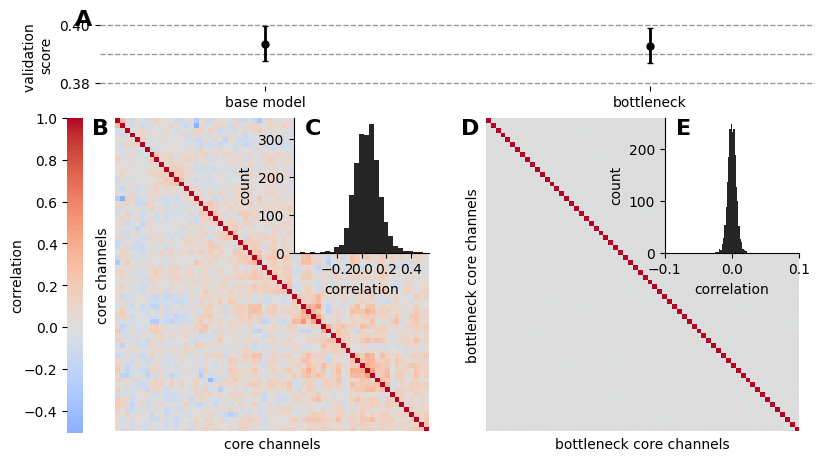

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

def plot_model_comparison(
    corr_base, corr_bottleneck,
    perf_mean, perf_std,
    labels=("Base model", "Bottleneck"),
    cluster_on="base",
    figsize=(8, 10),
    hist_bins=25,
    hist_size=("43%", "43%"),
    base_hist_ticks=(-0.2, 0, 0.2, 0.4),
    bottle_hist_ticks=(-0.1, 0, 0.1),
):
    corr_base = np.asarray(corr_base)
    corr_bottleneck = np.asarray(corr_bottleneck)

    # order via clustermap
    corr_for_order = corr_base if cluster_on.lower().startswith("base") else corr_bottleneck
    cg = sns.clustermap(corr_for_order)
    order = cg.dendrogram_row.reordered_ind
    plt.close(cg.fig)

    base_ord = corr_base[np.ix_(order, order)]
    bott_ord = corr_bottleneck[np.ix_(order, order)]

    fig = plt.figure(figsize=figsize, constrained_layout=True)
    #fig.subplots_adjust(left=0.15)  # room for cbar on left
    gs = fig.add_gridspec(nrows=2, ncols=2, height_ratios=[1.0, 5.0], hspace=0, wspace=0)

    ax_top = fig.add_subplot(gs[0, :])
    ax_h1  = fig.add_subplot(gs[1, 0])
    ax_h2  = fig.add_subplot(gs[1, 1])

    # ---- top: performance ----
    m = [perf_mean["base"], perf_mean["bottleneck"]] if isinstance(perf_mean, dict) else list(perf_mean)
    s = [perf_std["base"], perf_std["bottleneck"]]   if isinstance(perf_std, dict)  else list(perf_std)

    x = [0, 1]
    ax_top.errorbar(x, m, yerr=s, fmt='o', capsize=2, lw=2, markersize=5, c='black')
    ax_top.set_xticks(x)
    ax_top.set_xticklabels(labels)
    ax_top.set_ylabel("validation \nscore")
    ax_top.set_xlim(-0.43, 1.43)

    for y in (0.38, 0.39, 0.4):
        ax_top.axhline(y, color="0.6", lw=1, ls="--", zorder=0)

    ax_top.spines[['top', 'right', 'bottom', 'left']].set_visible(False)
    ax_top.text(-0.01, 0.9, 'A', transform=ax_top.transAxes,
                fontsize=16, fontweight='bold', va='bottom', ha='right')

    # ---- bottom: heatmaps + single colorbar on left ----
    vmax = np.nanmax([base_ord, bott_ord])
    vmin = np.nanmin([base_ord, bott_ord])

    cax = fig.add_axes([0.06, 0.05, 0.02, 0.7])  # [left, bottom, width, height]

    def heat(ax, data, cbar, label, cbar_ax=None):
        hm = sns.heatmap(
            data, ax=ax,
            cmap='coolwarm', center=0, square=True,
            vmin=vmin, vmax=vmax,
            cbar=cbar, cbar_ax=cbar_ax,
            xticklabels=False, yticklabels=False,
        )
        ax.set_xlabel(label)
        ax.set_ylabel(label)
        return hm

    hm1 = heat(ax_h1, base_ord, cbar=True, cbar_ax=cax, label='core channels')
    hm2 = heat(ax_h2, bott_ord, cbar=False, label='bottleneck core channels')

    cbar = hm1.collections[0].colorbar
    cbar.set_label("correlation", rotation=90, labelpad=0)
    cbar.ax.yaxis.set_label_position('left')
    cbar.ax.yaxis.tick_left()

    ax_h1.text(-0.02, 0.935, 'B', transform=ax_h1.transAxes,
               fontsize=16, fontweight='bold', va='bottom', ha='right')
    ax_h2.text(-0.02, 0.935, 'D', transform=ax_h2.transAxes,
               fontsize=16, fontweight='bold', va='bottom', ha='right')

    # ---- inset histograms (top-right overlay on each heatmap) ----
    def add_hist_inset(parent_ax, mat, panel_letter, hist_ticks):
        mat = np.asarray(mat)
        i, j = np.tril_indices(mat.shape[0], k=-1)
        corr_values = mat[i, j]

        axins = inset_axes(parent_ax, width=hist_size[0], height=hist_size[1],
                           loc="upper right", borderpad=0)
        axins.hist(corr_values, bins=hist_bins, color="black", alpha=0.85)

        # panel letter inside inset
        axins.text(0.2, 1, panel_letter, transform=axins.transAxes,
                   fontsize=16, fontweight='bold', va='top', ha='right')

        axins.set_xlabel('correlation')
        axins.set_ylabel('count')
        axins.set_xticks(list(hist_ticks))
        axins.spines['top'].set_visible(False)
        axins.spines['right'].set_visible(False)

    add_hist_inset(ax_h1, base_ord, "C", hist_ticks=base_hist_ticks)
    add_hist_inset(ax_h2, bott_ord, "E", hist_ticks=bottle_hist_ticks)

    return fig, (ax_top, ax_h1, ax_h2), order

# usage
fig, axes, order = plot_model_comparison(
    corr_base=base_corr,
    corr_bottleneck=bottle_corr,
    perf_mean=(base_mean, bottle_mean),
    perf_std=(base_std, bottle_std),
    labels=("base model", "bottleneck"),
    cluster_on="base",
    figsize=(8, 4.5),
)
#plt.tight_layout()
plt.savefig('plots/results_comparison.pdf')#, bbox_inches='tight')
plt.show()

In [20]:
bottle_mean - base_mean

tensor(-0.0007)